# Задержки вылетов рейсов США, январь–июнь 2026

## 1. Бизнес-постановка и управление проектом

**ML-задача:** бинарная классификация. Объект — запланированный рейс, целевая переменная — `DepDel15`: задержится ли вылет на 15 минут и больше (1 — да, 0 — нет).
Признаки — только то, что известно до вылета: дата, время по расписанию, авиакомпания, аэропорты и штаты вылета и прилёта, дистанция, время в пути по расписанию.
Всё, что становится известно после вылета (фактическое время, руление, прилёт, причины задержки), в признаки не берём — это утечка ответа.

Задержанных рейсов около четверти, поэтому accuracy будет обманчивой: константа «не задержится» угадывает ~77%. Метрики для обучения на следующей паре — ROC-AUC и PR-AUC.

**Распределение задач по CRISP-DM:**

| Этап CRISP-DM | Задачи | Роль | Участник |
|---|---|---|---|
| Business Understanding | формулировка ML-задачи, выбор целевой переменной и метрик | Руководитель |Манохин Ярослав |
| Data Understanding | выбор датасета, аудит размерности и структуры, описание колонок | Руководитель / Аналитик | Мамедова Гюнель |
| Data Understanding (EDA) | графики, анализ связи признаков с таргетом, выводы | Аналитик | Мамедова Гюнель |
| Data Preparation | поиск дефектов, пропуски, удаление признаков, фильтрация аномалий | Инженер данных | Ксения Силифанова |
| Data Preparation (экспорт) | проверка отсутствия пропусков, сохранение очищенной таблицы в CSV | ML-инженер | Лихачева Анна |
| Modeling / Evaluation | обучение и сравнение моделей (следующая пара) | ML-инженер | Манохин Ярослав |

In [1]:
%pip install -q pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: C:\Users\Iaroslav\AppData\Local\Temp\claude\C--Users-Iaroslav-Desktop--------ForkIT----------------v2\4f485f0d-e3d3-4c1f-874f-c70487cdeebc\scratchpad\nbenv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Аудит и описание данных

**Источник:** https://www.kaggle.com/datasets/hrishitpatil/flight-data-2024/data

Данные — отчётность авиакомпаний США о пунктуальности рейсов (On-Time Performance) за январь–июнь 2026: 3 488 373 рейса, 110 колонок.
Большая часть колонок — сведения о запасных аэродромах (`Div1…Div5`), почти целиком пустые, поэтому берём 34 колонки, имеющие отношение к задаче.
Чтобы тетрадка работала в веб-версии Jupyter, используем случайную выборку 10% рейсов — файл `flights_2026_sample.zip` (собран скриптом `make_sample.py`); в выборку добавлены и все 19 строк исходных данных с дефектами времени в пути, чтобы блок очистки работал на реальных ошибках.

In [3]:
df = pd.read_csv("flights_2026_sample.zip")
print("размерность загруженной таблицы:", df.shape)
df.head()

размерность загруженной таблицы: (348856, 34)


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,Origin,...,Diverted,CRSElapsedTime,Flights,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2026,1,1,2,5,2026-01-02,AA,N109NN,1,JFK,...,0.0,381.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN
1,2026,1,1,5,1,2026-01-05,AA,N104NN,1,JFK,...,0.0,387.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN
2,2026,1,1,7,3,2026-01-07,AA,N108NN,1,JFK,...,0.0,390.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN
3,2026,1,1,7,3,2026-01-07,AA,N774AN,3,JFK,...,0.0,377.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN
4,2026,1,1,9,5,2026-01-09,AA,N797AN,3,JFK,...,0.0,377.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN


**Структура таблицы (34 колонки):**

| Колонка | Что означает |
|---|---|
| `Year`, `Quarter`, `Month`, `DayofMonth` | год, квартал, месяц, число месяца |
| `DayOfWeek` | день недели (1 — понедельник, 7 — воскресенье) |
| `FlightDate` | дата рейса |
| `Reporting_Airline` | код авиакомпании (AA, DL, UA…) |
| `Tail_Number` | бортовой номер самолёта |
| `Flight_Number_Reporting_Airline` | номер рейса |
| `Origin`, `OriginState` | аэропорт и штат вылета |
| `Dest`, `DestState` | аэропорт и штат прилёта |
| `CRSDepTime` | время вылета по расписанию (ЧЧММ, местное) |
| `DepTime` | фактическое время вылета |
| `DepDelay` | задержка вылета, мин (отрицательная — вылет раньше расписания) |
| **`DepDel15`** | **таргет:** 1 — вылет задержан на 15+ мин, 0 — нет |
| `DepTimeBlk` | часовой интервал вылета по расписанию |
| `TaxiOut` | время руления до взлёта, мин |
| `CRSArrTime` | время прилёта по расписанию |
| `ArrDelay`, `ArrDel15` | задержка прилёта, мин, и флаг задержки прилёта на 15+ мин |
| `Cancelled`, `CancellationCode` | рейс отменён (1/0) и код причины отмены |
| `Diverted` | рейс ушёл на запасной аэродром (1/0) |
| `CRSElapsedTime` | время в пути по расписанию, мин |
| `Flights` | число рейсов в записи (всегда 1) |
| `Distance`, `DistanceGroup` | дистанция, мили, и её группа с шагом 250 миль |
| `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay` | минуты задержки по причинам: авиакомпания, погода, авиасистема, безопасность, поздний прилёт самолёта |

## 3. Очистка данных

### Первичный поиск дефектов

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 348856 entries, 0 to 348855
Data columns (total 34 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Year                             348856 non-null  int64  
 1   Quarter                          348856 non-null  int64  
 2   Month                            348856 non-null  int64  
 3   DayofMonth                       348856 non-null  int64  
 4   DayOfWeek                        348856 non-null  int64  
 5   FlightDate                       348856 non-null  str    
 6   Reporting_Airline                348856 non-null  str    
 7   Tail_Number                      347760 non-null  str    
 8   Flight_Number_Reporting_Airline  348856 non-null  int64  
 9   Origin                           348856 non-null  str    
 10  OriginState                      348856 non-null  str    
 11  Dest                             348856 non-null  str    
 12  DestState    

In [5]:
df.isna().sum()

Year                                    0
Quarter                                 0
Month                                   0
DayofMonth                              0
DayOfWeek                               0
FlightDate                              0
Reporting_Airline                       0
Tail_Number                          1096
Flight_Number_Reporting_Airline         0
Origin                                  0
OriginState                             0
Dest                                    0
DestState                               0
CRSDepTime                              0
DepTime                              7387
DepDelay                             7418
DepDel15                             7418
DepTimeBlk                              0
TaxiOut                              7608
CRSArrTime                              0
ArrDelay                             8607
ArrDel15                             8607
Cancelled                               0
CancellationCode                  

In [6]:
df.describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
Year,348856.0,2026.0,0.0,2026.0,2026.0,2026.0,2026.0,2026.0
Quarter,348856.0,1.5,0.5,1.0,1.0,2.0,2.0,2.0
Month,348856.0,3.6,1.7,1.0,2.0,4.0,5.0,6.0
DayofMonth,348856.0,15.6,8.7,1.0,8.0,16.0,23.0,31.0
DayOfWeek,348856.0,4.0,2.0,1.0,2.0,4.0,6.0,7.0
Flight_Number_Reporting_Airline,348856.0,2566.6,1627.7,1.0,1247.0,2316.0,3723.0,9910.0
CRSDepTime,348856.0,1326.6,492.1,5.0,905.0,1320.0,1736.0,2359.0
DepTime,341469.0,1332.0,510.1,1.0,907.0,1325.0,1747.0,2400.0
DepDelay,341438.0,14.0,59.7,-59.0,-6.0,-2.0,11.0,2888.0
DepDel15,341438.0,0.2,0.4,0.0,0.0,0.0,0.0,1.0


### Очистка

In [7]:
df = df[df.Cancelled == 0]
df.shape

(341215, 34)

Отменённые рейсы удаляем строками: они не вылетели, поэтому у них нет ни задержки вылета, ни таргета `DepDel15` — заполнять таргет нельзя, это была бы выдумка ответа.

In [8]:
df = df.drop(columns=[
    "Year", "Flights", "Cancelled", "CancellationCode",
    "Quarter", "DepTimeBlk", "DistanceGroup",
    "Tail_Number", "Flight_Number_Reporting_Airline",
    "DepTime", "DepDelay", "TaxiOut", "ArrDelay", "ArrDel15", "Diverted",
    "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"])
df.shape

(341215, 14)

`Year` и `Flights` — константы, а `Cancelled` и `CancellationCode` стали константой и пустой колонкой после удаления отменённых рейсов; `Quarter`, `DepTimeBlk` и `DistanceGroup` дублируют `Month`, `CRSDepTime` и `Distance`; бортовой номер и номер рейса — идентификаторы, которые не обобщаются на новые рейсы.
Фактическое время вылета, `DepDelay`, руление, всё о прилёте и причины задержки (пустые на 78%) становятся известны только после вылета — это утечка таргета, поэтому удаляем их, а не заполняем.

In [9]:
route_median = df.groupby(["Origin", "Dest"]).CRSElapsedTime.transform("median")
df["CRSElapsedTime"] = df.CRSElapsedTime.fillna(route_median).fillna(df.CRSElapsedTime.median())
df.CRSElapsedTime.isna().sum()

np.int64(0)

Пропуски времени в пути заполняем медианой по тому же маршруту: время полёта почти целиком определяется парой аэропортов, а медиана, в отличие от среднего, не сдвигается редкими ошибочными значениями (в данных есть даже отрицательные).
Если маршрут уникален, берём общую медиану.

In [10]:
speed = df.Distance / (df.CRSElapsedTime / 60)
anomaly = (df.CRSElapsedTime <= 0) | (speed > 600)
print("аномальных строк:", anomaly.sum())
df = df[~anomaly]
df.shape

аномальных строк: 12


(341203, 14)

Удаляем логически невозможные записи: время в пути по расписанию не может быть нулевым или отрицательным, а средняя скорость по расписанию выше 600 миль/ч превышает крейсерскую скорость пассажирских самолётов — это ошибки ввода расписания.

In [11]:
df["FlightDate"] = pd.to_datetime(df.FlightDate)
df["DepHour"] = df.CRSDepTime // 100 % 24
df["DepDel15"] = df.DepDel15.astype(int)
df.shape

(341203, 15)

Из времени вылета по расписанию выделяем час `DepHour`: формат ЧЧММ как число неравномерен (после 1259 идёт 1300), а час — понятная шкала для анализа. Таргет приводим к целому типу.

## 4. Разведочный анализ

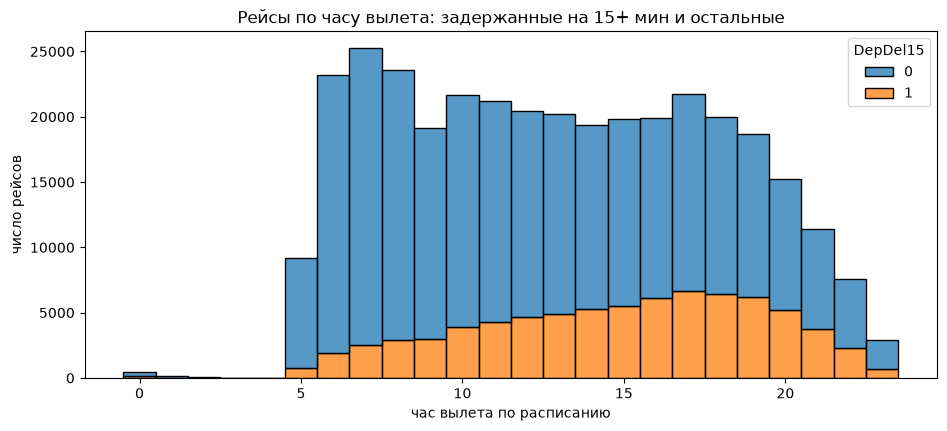

In [12]:
plt.figure(figsize=(11, 4.5))
sns.histplot(data=df, x="DepHour", hue="DepDel15", discrete=True, multiple="stack")
plt.title("Рейсы по часу вылета: задержанные на 15+ мин и остальные")
plt.xlabel("час вылета по расписанию")
plt.ylabel("число рейсов")
plt.show()

**Вывод:** доля задержанных вылетов растёт в течение дня почти монотонно: утром (5–7 ч) задерживается ~8% рейсов, вечером (18–21 ч) — 32–34%.
Задержки накапливаются: самолёт, опоздавший утром, везёт опоздание на все следующие рейсы дня. Час вылета — самый сильный из признаков, известных заранее.

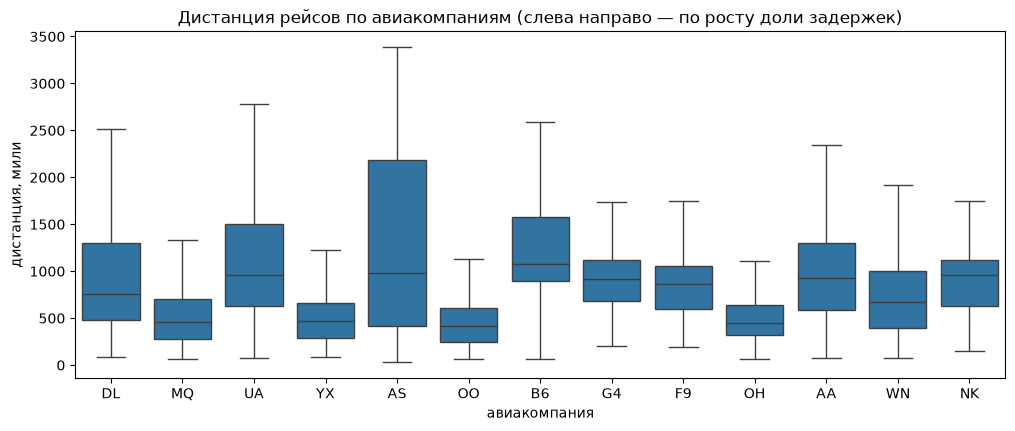

In [13]:
order = df.groupby("Reporting_Airline").DepDel15.mean().sort_values().index
plt.figure(figsize=(12, 4.5))
sns.boxplot(data=df, x="Reporting_Airline", y="Distance", order=order, showfliers=False)
plt.title("Дистанция рейсов по авиакомпаниям (слева направо — по росту доли задержек)")
plt.xlabel("авиакомпания")
plt.ylabel("дистанция, мили")
plt.show()

**Вывод:** дистанция с задержками не связана. Региональные перевозчики с короткими рейсами (YX, MQ, OO — медиана 410–480 миль) среди самых пунктуальных, а OH с такой же дистанцией (453 мили) — среди опаздывающих; дальнемагистральные AS и B6 тоже оказались по разные стороны.
Зато сама авиакомпания различает сильно: от 17% задержек у DL до 36% у NK.

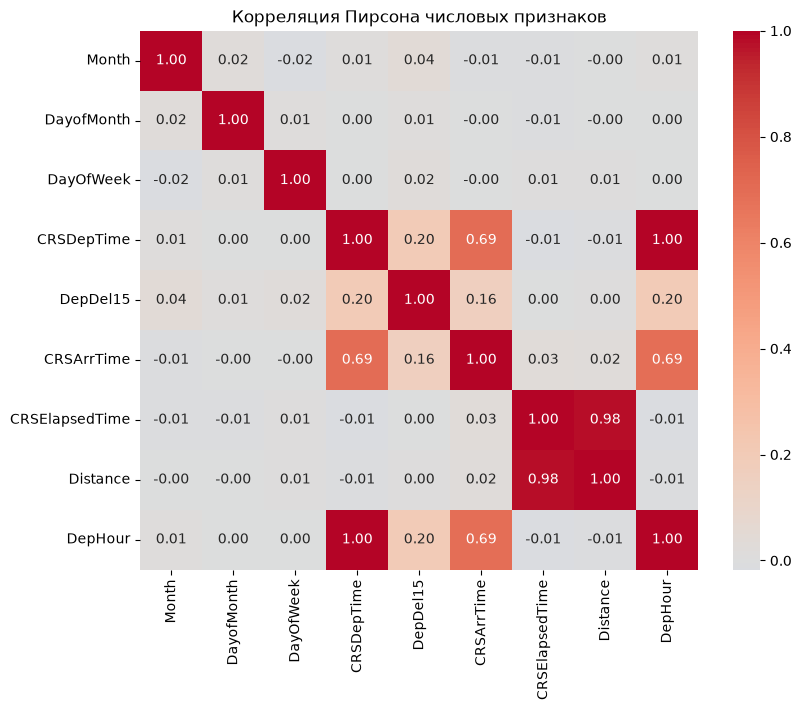

In [14]:
num = df.select_dtypes("number")
plt.figure(figsize=(9, 7))
sns.heatmap(num.corr(method="pearson"), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляция Пирсона числовых признаков")
plt.show()

**Вывод:** с таргетом `DepDel15` сильнее всего связаны время вылета (`DepHour`, `CRSDepTime` — 0.20) и время прилёта по расписанию (0.16); месяц даёт 0.04, день недели — 0.02, дистанция и время в пути не связаны вовсе (≤0.01).
Есть дубли: `DepHour` и `CRSDepTime` коррелируют на 1.00, `Distance` и `CRSElapsedTime` — на 0.98, для линейных моделей из каждой пары стоит оставить один признак.
Корреляция Пирсона считается только для числовых колонок и ловит только линейную связь, поэтому авиакомпания и аэропорты в матрицу не попали, а связь часа вылета с задержками (рост с 8% утром до 34% вечером) выглядит слабее, чем есть, — всего 0.20.

## 5. Финальный экспорт

In [15]:
assert df.isna().sum().sum() == 0
df.to_csv("flights_2026_clean.csv", index=False)
df.shape

(341203, 15)